In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import itertools
from statsmodels.tsa.stattools import pacf, acf
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from IPython.display import Image
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import classification_report, mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor

from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import time as thetime
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import PassiveAggressiveRegressor
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import TheilSenRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
import multiprocessing
from multiprocessing import Pool # To run models in multiple threads simultaneously

from Functions import *

### Read in necessary data

In [2]:
sensors = pd.read_csv('../Cleaned_data/validsensors.csv')
weather = pd.read_csv('../Cleaned_data/weather_data_allyears.csv')
public_holidays = pd.read_csv('../Cleaned_data/publicholidays.csv')
features_near_sensors= pd.read_csv('../Cleaned_data/num_features_near_sensors_100.csv', index_col=0)
feature_subtypes_near_sensors = pd.read_csv('../Cleaned_data/feature_subtypes_near_sensors_100.csv', index_col=0).T

### Create formatted dataframe

In [3]:
df = create_formatted_df(sensors, features_near_sensors, feature_subtypes_near_sensors, public_holidays, 
                                  weather)
# df = df[df['sensor_id'].isin([2,6,9,10,14,18])]
df

,sensor_id,hourly_counts,bikes,lights,furniture,landmarks,buildings,Monday,Saturday,Sunday,...,h_20,h_21,h_22,h_23,Temp,Humidity,Pressure,Rain,WindSpeed,public_holiday
0,9,241,0,57,77,0,1,0,1,0,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
1,8,325,0,826,43,1,0,0,1,0,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
2,18,233,1,0,86,1,23,0,1,0,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
3,11,2767,0,306,87,1,4,0,1,0,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
4,2,985,0,34,257,2,31,0,1,0,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707204,9,28,0,57,77,0,3,0,0,0,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0
707205,6,309,0,187,27,0,2,0,0,0,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0
707206,8,13,0,826,43,1,0,0,0,0,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0
707207,11,35,0,306,87,1,4,0,0,0,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0


In [4]:
df_subtypes = create_formatted_df(sensors, features_near_sensors, feature_subtypes_near_sensors, public_holidays, weather,
                        use_subtypes = True)
# df = df[df['sensor_id'].isin([2,6,9,10,14,18])]
df_subtypes

,sensor_id,hourly_counts,furniture_Bicycle Rails,furniture_Bollard,furniture_Drinking Fountain,furniture_Floral Crate/Planter Box,furniture_Information Pillar,furniture_Litter Bin,furniture_Seat,landmarks_Community Use,...,h_20,h_21,h_22,h_23,Temp,Humidity,Pressure,Rain,WindSpeed,public_holiday
0,9,241,49.0,13.0,NaN,NaN,NaN,13.0,2.0,NaN,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
1,8,325,10.0,28.0,NaN,NaN,2.0,3.0,NaN,NaN,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
2,18,233,27.0,25.0,1.0,NaN,NaN,20.0,8.0,NaN,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
3,11,2767,24.0,27.0,2.0,NaN,NaN,12.0,22.0,NaN,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
4,2,985,30.0,90.0,4.0,22.0,2.0,21.0,88.0,1.0,...,0,0,0,0,23.0,57.0,1008.0,0.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707204,9,28,49.0,13.0,NaN,NaN,NaN,13.0,2.0,NaN,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0
707205,6,309,3.0,NaN,NaN,NaN,NaN,12.0,12.0,NaN,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0
707206,8,13,10.0,28.0,NaN,NaN,2.0,3.0,NaN,NaN,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0
707207,11,35,24.0,27.0,2.0,NaN,NaN,12.0,22.0,NaN,...,0,0,0,1,8.0,82.0,1023.0,0.0,10.0,0.0


### Remove outliers

In [6]:
# df = remove_outliers(df)
df_subtypes = remove_outliers(df_subtypes)

I found 43968 outliers from 707209 days in total. Removing them leaves us with 663241 events


### Remove rows with NAs (these are for weather variables)
Model doesn't work if it includes NAs

In [10]:
df=df[df.Temp.notnull()]

In [11]:
df = df.drop(['Pressure', 'bikes'],axis=1)

## Modelling - Linear regression

#### Split into predictor and predictand variables

In [13]:
# The predictor variables
Xfull = df.drop(['hourly_counts'], axis =1)

# The variable to be predicted
Yfull = df['hourly_counts'].values

#### Split predictors and predictand into training and testing groups

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    Xfull, Yfull, test_size=0.2, random_state=1)

#### Standardize both training and testing data

In [15]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

#### Fit model

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
print('Training score: ', model.score(X_train, y_train))
print('Test score: ', model.score(X_test, y_test))
print('CV score: ', (cross_val_score(model, X_train, y_train)).mean())

Training score:  0.5537615513396889
Test score:  0.5539401721611212
CV score:  0.5535924250507847


In [18]:
predictions = model.predict(X_test)
residuals = pd.DataFrame({'Predictions':predictions,'RealValues': y_test})
residuals['residuals'] = residuals.RealValues - residuals.Predictions
residuals

,Predictions,RealValues,residuals
0,1415.660146,838,-577.660146
1,788.918577,81,-707.918577
2,541.070765,114,-427.070765
3,-47.750854,15,62.750854
4,133.251847,156,22.748153
...,...,...,...
98416,881.625532,2578,1696.374468
98417,1093.719430,1639,545.280570
98418,1745.805723,2124,378.194277
98419,613.716650,370,-243.716650


In [19]:
(mean_squared_error(y_test, predictions))**0.5

490.4674128053694

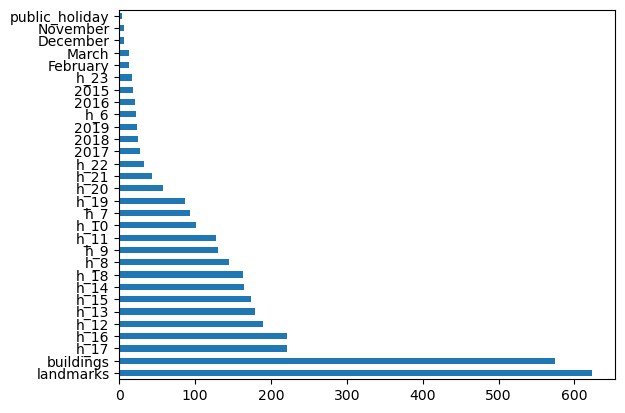

In [25]:
# collect the model coefficients in a dataframe
df_coef = pd.DataFrame(model.coef_, index=X_train.columns,
                       columns=['coefficients'])
# calculate the absolute values of the coefficients to gauge influence (show importance of predictor variables)
df_coef['coef_abs'] = df_coef.coefficients.abs()

# plot the magnitude of the coefficients
df_coef['coefficients'].sort_values(ascending = False)[:30].plot(kind='barh');

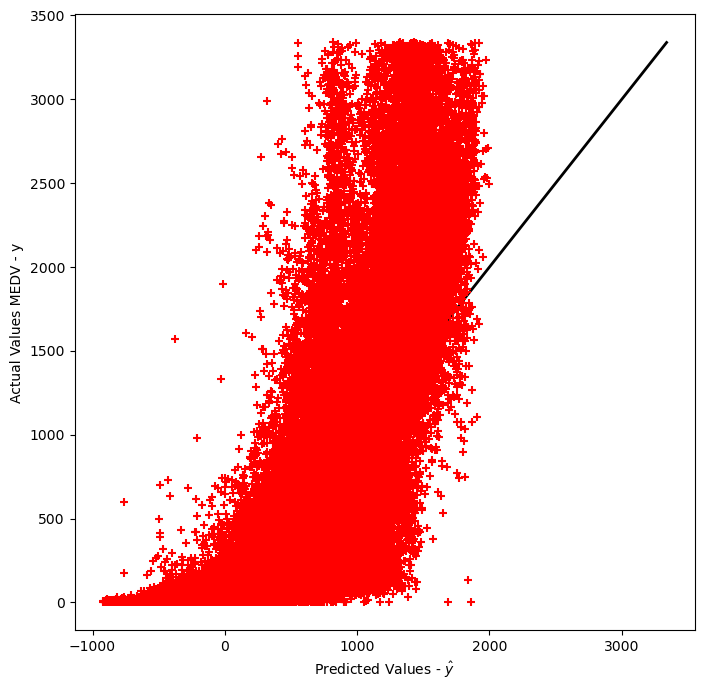

In [21]:
#predicted y values
predictions = model.predict(X_test)

#residuals (or error between predictions and actual)
residuals = y_test - predictions

# Plot predicted vs actual 
plt.figure(figsize=(8,8))
plt.scatter(predictions, y_test, s=30, c='r', marker='+', zorder=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], c='k', lw=2)
plt.xlabel("Predicted Values - $\hat{y}$")
plt.ylabel("Actual Values MEDV - y")
plt.show()

In [ ]:
# # Define a list of all the models to use
# Models = {'DecisionTree' : DecisionTreeRegressor, 'RandomForest': RandomForestRegressor, 
#           'ExtraTrees' : ExtraTreesRegressor,'DummyRegressor' :DummyRegressor, 
#           'ElasticNetCV' : ElasticNetCV, 'PassiveAggressive' : PassiveAggressiveRegressor,
#           # RANSAC': RANSACRegressor, # This one is terrible too
#           'SGD': SGDRegressor, 
#           #'TheilSen': TheilSenRegressor, # Drop this - it isn't great and takes too long
#           'KN': KNeighborsRegressor, 'LinearRegression': LinearRegression,
#           'XGBoost': xgb.XGBRegressor}

# # Now just run each model, but do this in multiple processes simultaneously to save time.

# # This function runs a model, returning a tuple containing:
# #  (name, model, r2 (all), median r2, mse (all), median mse, runtime).
# # It expects a tuple with (name,model_type)
# def run_model( x ):
#     name, model_type = x # Unpack the tuple
#     # See how long it takes to run this model
#     start = thetime.time()
#     # Use a pipeline to first scale the inputs (especially the weather)
#     model = Pipeline (
#         [ ('standardize', MinMaxScaler(feature_range = (0,1))), 
#          (name, model_type())]
#     )
#     # Evaluate the pipeline (run the model)
#     kfold = KFold(n_splits=10, random_state=7, shuffle = True)
#     mse = cross_val_score(model, X_train, y_train, cv=kfold, scoring = 'neg_mean_squared_error')
#     r2 = cross_val_score(model, X_train, y_train, cv=kfold, scoring = 'r2')
    
#     # See how long it took (in seconds)
#     runtime = int(thetime.time() - start)
#     # Return the results, taking the median of the errors
#     return (name, model, r2, np.median(r2), mse, np.median(mse), runtime)
    
# # Now call that function simultaneously for each model
# p = Pool(processes=None) # A pool of processes (one for each core)
# results = p.map(run_model, [(name, model_type) for name, model_type in Models.items()])

# # Sort the results by median mse (that's item 5 in the tuple)
# results.sort(key=lambda x: x[5], reverse=True)

# # Put the results in a nice dictionary and print them
# results_dict = {}
# txt = ""

# for name, model, all_r2, r2, all_mse, mse, runtime in results:
#     txt += "{}{}{}{}".format(name, r2, mse, runtime)
#     results_dict[name] = (model, all_r2, r2, all_mse, mse, runtime)

# display(HTML(txt)) # print as html

#### Ridge with GridSearchCV

In [76]:
parameters = {'alpha': list(range(10)), 'fit_intercept': [True, False], 
              'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']}

# define the model/ estimator
model = Ridge(max_iter = 100000)

# define the grid search
ridge= GridSearchCV(model, parameters,cv=5)

#fit the grid search
ridge.fit(X_train,y_train)

# best estimator
print(ridge.best_estimator_)

# best model
best_model = ridge.best_estimator_
best_model.fit(X_train,y_train)

KeyboardInterrupt: 

In [139]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.8310290311652919
Test score:  0.8302931666900183
CV score:  0.8306522518062962


#### Lasso with GridSearchCV

In [140]:
parameters = {'alpha': np.logspace(-4, 4, 10), 'fit_intercept': [True, False]}

# define the model/ estimator
model = Lasso(max_iter = 100000)

# define the grid search
lasso= GridSearchCV(model, parameters,cv=5)

#fit the grid search
lasso.fit(X_train,y_train)

# best estimator
print(lasso.best_estimator_)

# best model
best_model = lasso.best_estimator_
best_model.fit(X_train,y_train)

Lasso(alpha=0.0001, copy_X=True, fit_intercept=True, max_iter=100000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)


Lasso(alpha=0.0001, copy_X=True, fit_intercept=True, max_iter=100000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)

In [141]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.8310291574249858
Test score:  0.8302997445721232
CV score:  0.8306526367044093


#### Decision Tree Regressor with GridSearchCV

In [29]:
dtr_params = {
    'max_depth': list(range(1, 11))+[None],
    'max_features': [None, 1, 2, 3],
    'min_samples_split': [2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50],
    'ccp_alpha': [0, 0.001, 0.005, 0.009, 0.01, 0.05]
}


# set the gridsearch
model = DecisionTreeRegressor()
dtr_gs = GridSearchCV(model, dtr_params, cv=5, verbose=1, n_jobs=2)
dtr_gs.fit(X_train, y_train)
print(dtr_gs.best_params_)
best_model = dtr_gs.best_estimator_

Fitting 5 folds for each of 2904 candidates, totalling 14520 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    8.0s
[Parallel(n_jobs=2)]: Done 203 tasks      | elapsed:   17.5s
[Parallel(n_jobs=2)]: Done 703 tasks      | elapsed:   51.8s
[Parallel(n_jobs=2)]: Done 1403 tasks      | elapsed:  1.9min
[Parallel(n_jobs=2)]: Done 1935 tasks      | elapsed:  3.1min
[Parallel(n_jobs=2)]: Done 2485 tasks      | elapsed:  4.6min
[Parallel(n_jobs=2)]: Done 3654 tasks      | elapsed:  5.9min
[Parallel(n_jobs=2)]: Done 4404 tasks      | elapsed:  7.5min
[Parallel(n_jobs=2)]: Done 5364 tasks      | elapsed: 10.1min
[Parallel(n_jobs=2)]: Done 6834 tasks      | elapsed: 12.5min
[Parallel(n_jobs=2)]: Done 8139 tasks      | elapsed: 16.2min
[Parallel(n_jobs=2)]: Done 9312 tasks      | elapsed: 18.5min
[Parallel(n_jobs=2)]: Done 11295 tasks      | elapsed: 23.5min
[Parallel(n_jobs=2)]: Done 13082 tasks      | elapsed: 28.4min
[Parallel(n_jobs=2)]: Done 14520 out of 14520 | elapsed: 3

{'ccp_alpha': 0, 'max_depth': None, 'max_features': None, 'min_samples_split': 50}


In [30]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.9440709074505427
Test score:  0.9190303296751863
CV score:  0.9170065066191808


# Use all sensors to predict 2017 & 2018 data
#### predict hourly counts with location, date and previous year's counts as predictors
#### using all valid sensors from 2011-2018
#### predict counts for 2017 & 2018 with previous years as train data
*best CV score = Ada Boost Regressor 0.84

In [15]:
train = pd.concat([all_sen_2012, all_sen_2013, all_sen_2014, all_sen_2015, all_sen_2016], axis = 0, sort = True)
test = pd.concat([all_sen_2018, all_sen_2017], axis = 0, sort = True)

X_train = train.copy()
y_train = X_train.pop('daily_avg_counts')

X_test = test.copy()
y_test = X_test.pop('daily_avg_counts')

In [16]:
X_train

,Barbeque,Bicycle Rails,Bin Corral,Bollard,Commercial Accommodation,Community Use,Community Use.1,Drinking Fountain,Education Centre,Educational/Research,...,Workshop/Studio,avg_n_floors,day,month,num_bikes,num_lights,prev_year_counts,sensor_id,weekday,year
0,0,26,0,80,1.0,1,0.0,3,0,1.0,...,0.0,6.266667,1,1,0,44,816.875000,2,6,2012
1,0,26,0,80,1.0,1,0.0,3,0,1.0,...,0.0,6.266667,2,1,0,44,1096.375000,2,0,2012
2,0,26,0,80,1.0,1,0.0,3,0,1.0,...,0.0,6.266667,3,1,0,44,1022.583333,2,1,2012
3,0,26,0,80,1.0,1,0.0,3,0,1.0,...,0.0,6.266667,4,1,0,44,1252.500000,2,2,2012
4,0,26,0,80,1.0,1,0.0,3,0,1.0,...,0.0,6.266667,5,1,0,44,1307.375000,2,3,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,0,34,0,15,4.0,0,0.0,1,0,1.0,...,0.0,14.250000,27,12,0,13,124.541667,40,1,2016
342,0,34,0,15,4.0,0,0.0,1,0,1.0,...,0.0,14.250000,28,12,0,13,124.375000,40,2,2016
343,0,34,0,15,4.0,0,0.0,1,0,1.0,...,0.0,14.250000,29,12,0,13,189.791667,40,3,2016
344,0,34,0,15,4.0,0,0.0,1,0,1.0,...,0.0,14.250000,30,12,0,13,226.375000,40,4,2016


In [17]:
X_test

,Barbeque,Bicycle Rails,Bin Corral,Bollard,Commercial Accommodation,Community Use,Community Use.1,Drinking Fountain,Education Centre,Educational/Research,...,Workshop/Studio,avg_n_floors,day,month,num_bikes,num_lights,prev_year_counts,sensor_id,weekday,year
0,0,31,0,77,2.0,1,0.0,4,0,0.0,...,0.0,5.096354,1,1,0,56,972.166667,1,0,2018
1,0,31,0,77,2.0,1,0.0,4,0,0.0,...,0.0,5.096354,2,1,0,56,1060.000000,1,1,2018
2,0,31,0,77,2.0,1,0.0,4,0,0.0,...,0.0,5.096354,3,1,0,56,1393.125000,1,2,2018
3,0,31,0,77,2.0,1,0.0,4,0,0.0,...,0.0,5.096354,4,1,0,56,1409.958333,1,3,2018
4,0,31,0,77,2.0,1,0.0,4,0,0.0,...,0.0,5.096354,5,1,0,56,1412.750000,1,4,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,0,19,0,22,3.0,0,0.0,1,0,1.0,...,1.0,11.336111,27,12,0,0,676.708333,53,2,2017
361,0,19,0,22,3.0,0,0.0,1,0,1.0,...,1.0,11.336111,28,12,0,0,751.875000,53,3,2017
362,0,19,0,22,3.0,0,0.0,1,0,1.0,...,1.0,11.336111,29,12,0,0,644.125000,53,4,2017
363,0,19,0,22,3.0,0,0.0,1,0,1.0,...,1.0,11.336111,30,12,0,0,741.458333,53,5,2017


In [18]:
#standardize
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

### Linear Regression

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [45]:
print('Training score: ', model.score(X_train, y_train))
print('Test score: ', model.score(X_test, y_test))
print('CV score: ', (cross_val_score(model, X_train, y_train)).mean())

Training score:  0.8406975290646816
Test score:  -1.8586066410080133
CV score:  -9.704126178885058e+23


In [46]:
predictions = model.predict(X_test)
residuals = pd.DataFrame(predictions, y_test)
residuals.reset_index(inplace = True)
residuals.rename({'daily_avg_counts': 'y_test', 0: 'predictions'}, axis = 1, inplace = True)
residuals['residuals'] = residuals.y_test - residuals.predictions
residuals

,y_test,predictions,residuals
0,1170.208333,1370.529475,-200.321142
1,1263.916667,1385.283332,-121.366665
2,1400.750000,1473.334315,-72.584315
3,1459.333333,1466.872221,-7.538888
4,1549.666667,1456.214250,93.452417
...,...,...,...
26171,703.416667,3216.488052,-2513.071386
26172,722.958333,3227.456904,-2504.498571
26173,754.666667,3183.767291,-2429.100624
26174,634.541667,3201.359902,-2566.818235


In [47]:
(mean_squared_error(y_test, predictions))**0.5

798.1630962458429

### Ridge with GridSearchCV

In [49]:
parameters = {'alpha': np.logspace(-20, 20, 50), 'fit_intercept': [True, False], 
              'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']}

# define the model/ estimator
model = Ridge(max_iter = 100000)

# define the grid search
ridge= GridSearchCV(model, parameters,cv=5)

#fit the grid search
ridge.fit(X_train,y_train)

# best estimator
print(ridge.best_estimator_)

# best model
best_model = ridge.best_estimator_
best_model.fit(X_train,y_train)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.66391e-26): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.47631e-26): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.53971e-26): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.66391e-26): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.47631e-26): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_mo

/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.48111e-24): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=6.93874e-24): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=7.14129e-24): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=4.90711e-23): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=4.56154e-23): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_mo

/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.37807e-20): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.27817e-20): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.31548e-20): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.37807e-20): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=1.27817e-20): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_mo

/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.54162e-17): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.36264e-17): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.42313e-17): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.53851e-17): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_ridge.py:148: LinAlgWarning: Ill-conditioned matrix (rcond=2.35447e-17): result may not be accurate.
  overwrite_a=True).T
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_mo

Ridge(alpha=4714.8663634573895, copy_X=True, fit_intercept=True,
      max_iter=100000, normalize=False, random_state=None, solver='lsqr',
      tol=0.001)


Ridge(alpha=4714.8663634573895, copy_X=True, fit_intercept=True,
      max_iter=100000, normalize=False, random_state=None, solver='lsqr',
      tol=0.001)

In [50]:
# Ridge(alpha=4714.8663634573895, copy_X=True, fit_intercept=True,
#       max_iter=100000, normalize=False, random_state=None, solver='lsqr',
#       tol=0.001)

print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.8134001838445514
Test score:  0.7294065083456526
CV score:  0.7070539072101909


### Lasso with GridSearchCV

In [17]:
parameters = {'alpha': np.logspace(-4, 4, 10), 'fit_intercept': [True, False]}

# define the model/ estimator
model = Lasso(max_iter = 100000)

# define the grid search
lasso= GridSearchCV(model, parameters,cv=5)

#fit the grid search
lasso.fit(X_train,y_train)

# best estimator
print(lasso.best_estimator_)

# best model
best_model = lasso.best_estimator_
best_model.fit(X_train,y_train)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 443593048.3594327, tolerance: 598106.0068619931
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 518887008.043306, tolerance: 641836.5967190965
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 482318139.3136526, tolerance: 641215.9969709492
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality ga

/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 121341965.46083832, tolerance: 1722835.4675249902
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 37082952.33601558, tolerance: 1973850.7752070448
  positive)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2907471.945663452, tolerance: 1569705.738421021
  positive)


Lasso(alpha=21.54434690031882, copy_X=True, fit_intercept=True, max_iter=100000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)


Lasso(alpha=21.54434690031882, copy_X=True, fit_intercept=True, max_iter=100000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)

Lasso(alpha=21.54434690031882, copy_X=True, fit_intercept=True, max_iter=100000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)

In [18]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.7710263428895594
Test score:  0.811900930429534
CV score:  0.7129071721138106


In [20]:
predictions = best_model.predict(X_test)
residuals = pd.DataFrame(predictions, y_test)
residuals.reset_index(inplace = True)
residuals.rename({'daily_avg_counts': 'y_test', 0: 'predictions'}, axis = 1, inplace = True)
residuals['residuals'] = residuals.y_test - residuals.predictions
residuals

,y_test,predictions,residuals
0,1170.208333,1028.394203,141.814130
1,1263.916667,1086.843825,177.072842
2,1400.750000,1340.279819,60.470181
3,1459.333333,1342.290375,117.042958
4,1549.666667,1333.138979,216.527687
...,...,...,...
26171,703.416667,636.776185,66.640481
26172,722.958333,685.156866,37.801468
26173,754.666667,588.134084,166.532582
26174,634.541667,654.135412,-19.593745


In [21]:
(mean_squared_error(y_test, predictions))**0.5

204.74238992999986

In [27]:
from sklearn.metrics import r2_score
r2_score(y_test, predictions)

0.811900930429534

In [35]:
# collect the model coefficients in a dataframe
df_coef = pd.DataFrame(best_model.coef_, index=X_train.columns,
                       columns=['coefficients'])
# calculate the absolute values of the coefficients to gauge influence (show importance of predictor variables)
df_coef['coef_abs'] = df_coef.coefficients.abs()

df_coef.sort_values(by = 'coefficients')[-50:]

,coefficients,coef_abs
Barbeque,-0.000000,0.000000
Unoccupied - Under Construction,-0.000000,0.000000
Unoccupied - Under Demolition/Condemned,-0.000000,0.000000
Unoccupied - Under Renovation,0.000000,0.000000
Unoccupied - Unused,-0.000000,0.000000
Vacant Land,0.000000,0.000000
Warehouse/Store,0.000000,0.000000
Wholesale,-0.000000,0.000000
Workshop/Studio,0.000000,0.000000
avg_n_floors,-0.000000,0.000000


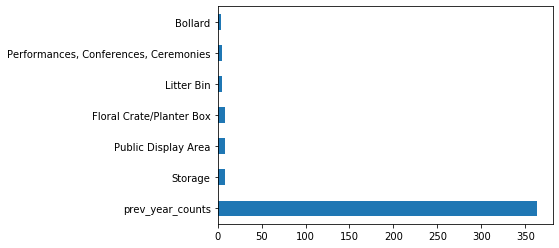

In [36]:
# 7 factors that have the greatest impact on predicting daily footfall counts
df_coef['coefficients'].sort_values(ascending = False)[:7].plot(kind='barh');

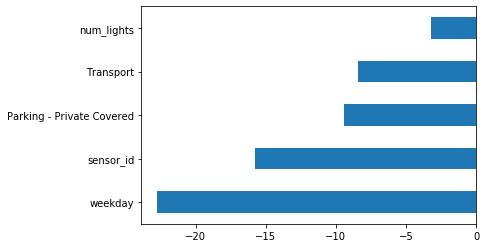

In [30]:
# 5 factors that have least impact on hourly counts
df_coef['coefficients'].sort_values(ascending = True)[:5].plot(kind='barh');

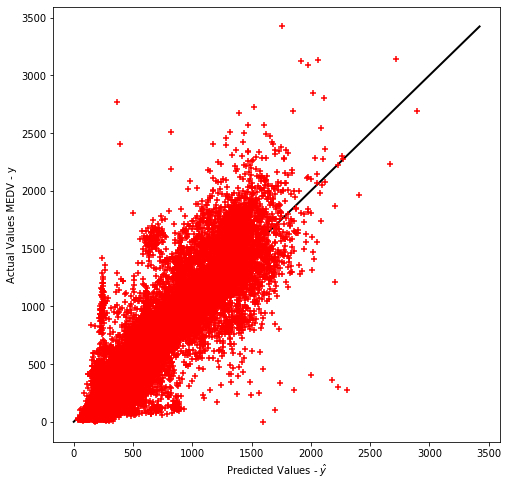

In [23]:
#predicted y values
predictions = best_model.predict(X_test)

#residuals (or error between predictions and actual)
residuals = y_test - predictions

# Plot predicted vs actual 
plt.figure(figsize=(8,8))
plt.scatter(predictions, y_test, s=30, c='r', marker='+', zorder=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], c='k', lw=2)
plt.xlabel("Predicted Values - $\hat{y}$")
plt.ylabel("Actual Values MEDV - y")
plt.show()

### Decision Tree Regressor

In [23]:
dtr_params = {
    'max_depth': [10, 15, 20],
    'max_features': [None],
    'min_samples_split': [48, 50, 52, 60, 70],
    'ccp_alpha': [0.004, 0.005, 0.006, 0.007]}

# set the gridsearch
model = DecisionTreeRegressor()

dtr_gs = GridSearchCV(model, dtr_params, cv=5, verbose=1, n_jobs=2)
dtr_gs.fit(X_train, y_train)
print(dtr_gs.best_params_)
best_model = dtr_gs.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    5.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   24.5s


{'ccp_alpha': 0.006, 'max_depth': 10, 'max_features': None, 'min_samples_split': 50}


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:   36.8s finished


In [24]:
#{'ccp_alpha': 0.005, 'max_depth': 10, 'max_features': None, 'min_samples_split': 50}
# Training score:  0.9318641103420108
# Test score:  0.7726691799695199
# CV score:  0.7755289534003487

In [26]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.9318641103420108
Test score:  0.7714581127741083
CV score:  0.7668497986142154


### Ada Boost Regressor

In [21]:
base_estimator = DecisionTreeRegressor()

params = {'n_estimators': [71, 72, 73, 74, 75], 'learning_rate': [1.0], #.001, .01, .1, .5, .8,
         'loss': [ 'square' ]} #'linear','exponential'
model = AdaBoostRegressor(base_estimator=base_estimator,
                          random_state=1)

ada_cv = GridSearchCV(model, params, cv=5, verbose=1, n_jobs=2)

ada_cv.fit(X_train, y_train)
print(ada_cv.best_params_)
best_model = ada_cv.best_estimator_




Fitting 5 folds for each of 5 candidates, totalling 25 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  25 out of  25 | elapsed:  5.9min finished


{'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 74}


In [ ]:
#{'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 70}
# Training score:  0.998341276457725
# Test score:  0.8285804223494496
# CV score:  0.8396797711244777

#{'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 75}
# Training score:  0.998290994561775
# Test score:  0.8278697054392621
# CV score:  0.840544556784628

#{'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 74}
# Training score:  0.9983166566529816
# Test score:  0.8275409714613514
# CV score:  0.8405586581229854

In [22]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.9983166566529816
Test score:  0.8275409714613514
CV score:  0.8405586581229854


# Use all sensors to predict just 2018

#### predict hourly counts with location, date and previous year's counts as predictors
#### using all valid sensors from 2011-2018
#### predict counts for 2018 with previous years as train data

*best CV score = Ada Boost Regressor 0.874

In [98]:
train = pd.concat([all_sen_2012, all_sen_2013, all_sen_2014, all_sen_2015, all_sen_2016, all_sen_2017], axis = 0, sort = True)
test = pd.concat([all_sen_2018], axis = 0, sort = True)

#remove sensor_id from predictors

train.pop('sensor_id')
test.pop('sensor_id')

X_train = train.copy()
y_train = X_train.pop('daily_avg_counts')

X_test = test.copy()
y_test = X_test.pop('daily_avg_counts')

### Ada Boost Regressor

In [101]:
base_estimator = DecisionTreeRegressor()

params = {'n_estimators': [75, 80, 85], 'learning_rate': [0.85, 0.9, .95], 'loss': ['square']}
model = AdaBoostRegressor(base_estimator=base_estimator,
                          random_state=1)

ada_cv = GridSearchCV(model, params, cv=5, verbose=1, n_jobs=2)

ada_cv.fit(X_train, y_train)
print(ada_cv.best_params_)
best_model = ada_cv.best_estimator_



Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  45 out of  45 | elapsed: 19.2min finished


{'learning_rate': 0.9, 'loss': 'square', 'n_estimators': 80}


In [ ]:
## with sensor id included

#{'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 71}
# Training score:  0.9987605835914849
# Test score:  0.8523777471089019
# CV score:  0.8822139478108436

#{'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 60}
# Training score:  0.9989029209378538
# Test score:  0.8586228286379924
# CV score:  0.8849978086354005

##without sensor id included
# {'learning_rate': 0.9, 'loss': 'square', 'n_estimators': 80}
# Training score:  0.9994441664008715
# Test score:  0.9031665569172646
# CV score:  0.8743541418637856

In [105]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.9994441664008715
Test score:  0.9031665569172646
CV score:  0.8743541418637856


In [106]:
predictions = best_model.predict(X_test)


In [107]:
(mean_squared_error(y_test, predictions))**0.5

158.76326020224184

In [108]:
residuals_df = pd.DataFrame(predictions, y_test)
residuals_df.reset_index(inplace = True)
residuals_df.rename({'daily_avg_counts': 'y_test', 0: 'predictions'}, axis = 1, inplace = True)
residuals_df['residuals'] = residuals_df.y_test - residuals_df.predictions
residuals_df

,y_test,predictions,residuals
0,1170.208333,722.458333,447.750000
1,1263.916667,982.541667,281.375000
2,1400.750000,1435.708333,-34.958333
3,1459.333333,1459.375000,-0.041667
4,1549.666667,1518.250000,31.416667
...,...,...,...
13393,639.041667,751.958333,-112.916667
13394,704.500000,812.833333,-108.333333
13395,608.375000,634.541667,-26.166667
13396,527.500000,592.125000,-64.625000


In [109]:
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
})

fi.sort_values('importance', ascending=True, inplace=True)


Text(0, 0.5, 'Feature')

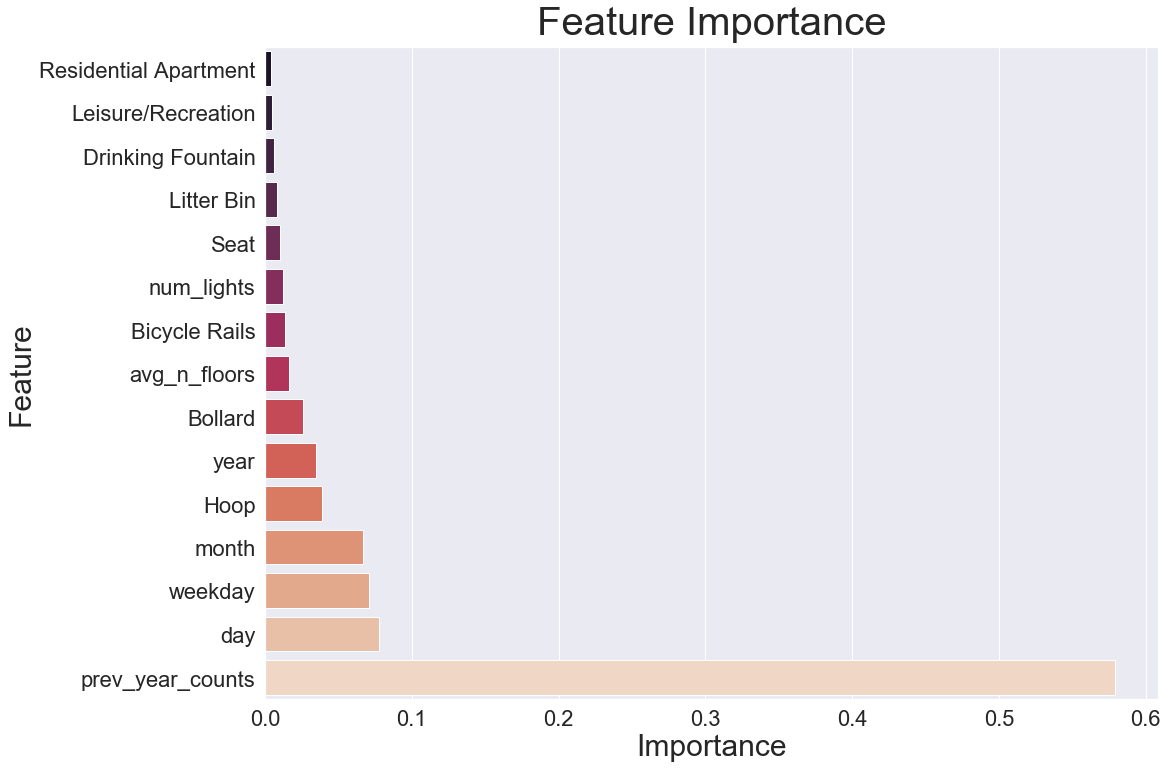

In [110]:
#sns.set_style('ticks')
sns.set(font_scale = 2)
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(16, 12)
sns.barplot(x='importance', y='feature', data=fi[-15:], orient='h', palette = 'rocket', saturation=0.7)  
ax.set_title("Feature Importance", fontsize=40, y=1.01)
ax.set_xlabel('Importance', fontsize = 30)
ax.set_ylabel('Feature', fontsize = 30)

Text(0, 0.5, 'Actual')

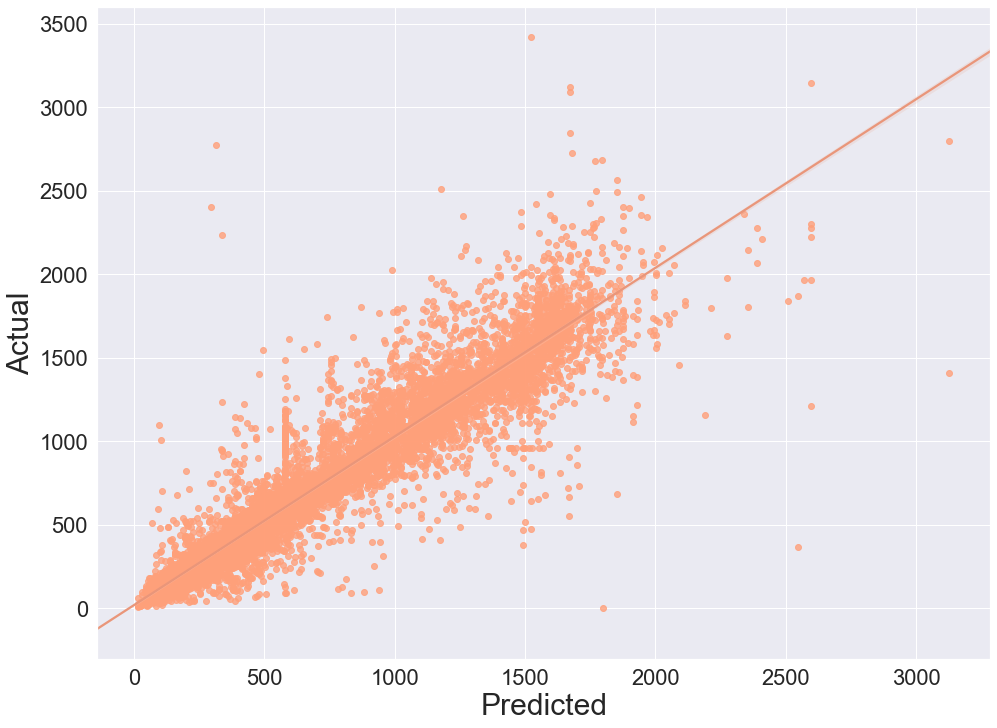

In [111]:
#predicted y values
predictions = best_model.predict(X_test)

#residuals (or error between predictions and actual)
residuals = y_test - predictions

sns.axes_style(style='white')

sns.set(font_scale = 2)
fig, ax = plt.subplots()
fig.set_size_inches(16, 12)
ax = sns.regplot(x="predictions", y="y_test", data= residuals_df,  scatter_kws = {'color': 'lightsalmon'}, 
                 line_kws = {'color': 'darksalmon'})
ax.set_xlabel('Predicted', fontsize = 30)
ax.set_ylabel('Actual', fontsize = 30)


### Decision Tree Regressor

In [37]:
dtr_params = {
    'max_depth': [5, 10, 15, 20,50],
    'max_features': [10, 50, None],
    'min_samples_split': [10, 20, 40, 50, 70],
    'ccp_alpha': [0.001, 0.005, 0.01, 0.1]}

# set the gridsearch
model = DecisionTreeRegressor()

dtr_gs = GridSearchCV(model, dtr_params, cv=5, verbose=1, n_jobs=2)
dtr_gs.fit(X_train, y_train)
print(dtr_gs.best_params_)
best_model = dtr_gs.best_estimator_

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    5.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   24.9s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:  1.0min
[Parallel(n_jobs=2)]: Done 796 tasks      | elapsed:  1.9min
[Parallel(n_jobs=2)]: Done 1246 tasks      | elapsed:  2.9min
[Parallel(n_jobs=2)]: Done 1500 out of 1500 | elapsed:  3.6min finished


{'ccp_alpha': 0.005, 'max_depth': 10, 'max_features': None, 'min_samples_split': 70}


In [38]:
print('Training score: ', best_model.score(X_train, y_train))
print('Test score: ', best_model.score(X_test, y_test))
print('CV score: ', (cross_val_score(best_model, X_train, y_train)).mean())

Training score:  0.9267420084089457
Test score:  0.7624814399889087
CV score:  0.849740484551322
